In [46]:
import numpy as np
import matplotlib.pyplot as plt

def exactsolution(x):
    return np.exp(-2*np.sin(x))

def f(x, y):
    return -2*y*np.cos(x)

def lambda_val(x=0):
    return -2 * np.cos(x)

def eulerapprox(h, x_start, x_end):
    # Define parameter # step size
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Exact Solution as Reference
    y = exactsolution(x_values)
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    # Error Calcs
    y_reference = y.copy()
    x_reference = x_values.copy()
        
    ylen = min(len(y_reference), len(y_values))
    global_error = np.abs(y_values[:ylen] - y_reference[:ylen])
    local_error = np.zeros_like(x_values)

    for i in range(len(x_values)-1):
        y_true_next = exactsolution(x_values[i+1])
        y_taylor = exactsolution(x_values[i]) + h * f(x_values[i], exactsolution(x_values[i]))
        local_error[i+1] = abs(y_true_next - y_taylor)
        
    # Plot the results
    plt.plot(x_values, y_values, label="h = " +str(h))
    
    # X = 15 Index
    index = np.argmin(np.abs(x_values - 15))
    
    return np.mean(y_values), np.mean(local_error), local_error[index]

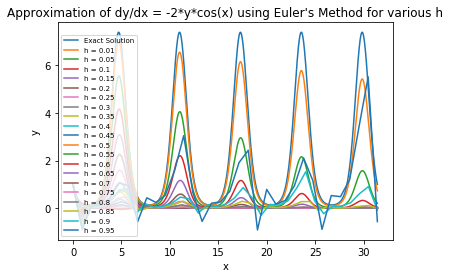

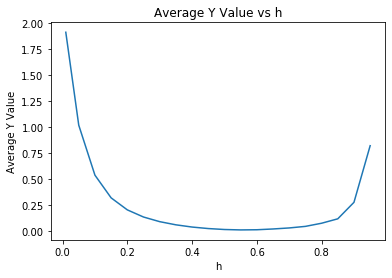

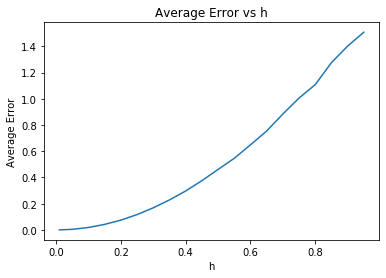

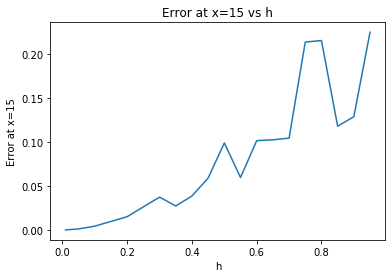

λ = -2.0
System is analytically/asymptotically stable (λ < 0)
System is stable if h < 1.0


In [49]:
yavgs = []
eavgs = []
hs = []
x15errors = []

x = np.linspace(0, 10*np.pi, 100000)
plt.plot(x, exactsolution(x), label="Exact Solution")

y_avg, e_avg, x15error = eulerapprox(.01,0,10*np.pi)
yavgs.append(y_avg)
eavgs.append(e_avg)
x15errors.append(x15error)
hs.append(.01)

for h in range (5,100,5):
    h = h/100
    y_avg, e_avg, x15error = eulerapprox(h,0,10*np.pi)
    yavgs.append(y_avg)
    eavgs.append(e_avg)
    x15errors.append(x15error)
    hs.append(h)

plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2*y*cos(x) using Euler's Method for various h")
plt.legend(fontsize=7)
plt.show()

plt.plot(hs, yavgs)
plt.xlabel('h')
plt.ylabel('Average Y Value')
plt.title("Average Y Value vs h")
plt.show()

plt.plot(hs, eavgs)
plt.xlabel('h')
plt.ylabel('Average Error')
plt.title("Average Error vs h")
plt.show()

plt.plot(hs, x15errors)
plt.xlabel('h')
plt.ylabel('Error at x=15')
plt.title("Error at x=15 vs h")
plt.show()

lam = lambda_val(x=0)
print(f"λ = {lam}")

if lam < 0:
    print("System is analytically/asymptotically stable (λ < 0)")
    h_max = 2 / abs(lam)
    print(f"System is stable if h < {h_max}")
else:
    print("System is unstable (λ > 0)")

Through these plots, we are able to see how change in step size, h, affects graph accuracy, resolution, and the average/local error. The trend shows that at h increases the average error increases, however local error at certain points oscillates but generally trends up due to the base function being a cosine function. This is shown by the graph analyzing x=15.